# Project 7 — Skin Cancer Detection

**Dataset:** HAM10000  
**Target:** >80% Melanoma Recall  
**Model:** EfficientNetV2-S (Transfer Learning, Fine-Tuned)

## 1. Environment Setup

### 1.1 Kaggle Authentication

In [1]:
!pip install -q kaggle
import os
from google.colab import files
uploaded = files.upload()
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'wb') as f:
    f.write(uploaded['kaggle.json'])
os.chmod('/root/.kaggle/kaggle.json', 0o600)

Saving kaggle.json to kaggle.json


### 1.2 Dataset Download

In [2]:
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -p /content/ham10000 --unzip -q
print('Dataset ready.')

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
Dataset ready.


## 2. Imports & Configuration

In [10]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

DEVICE    = 'cuda' if torch.cuda.is_available() else 'cpu'
IMG_SIZE  = 224
BATCH     = 32
EPOCHS    = 25
LR        = 3e-4
SEED      = 42
SAVE_PATH = 'skin_cancer_model.pth'

CLASS_NAMES = ['akiec','bcc','bkl','df','mel','nv','vasc']
LABEL_MAP   = {c: i for i, c in enumerate(CLASS_NAMES)}
MEL_IDX     = LABEL_MAP['mel']   # 4

torch.manual_seed(SEED); np.random.seed(SEED)
print(f'Device: {DEVICE}')

Device: cuda


## 3. Data Loading & Preparation

### 3.1 Build DataFrame

In [11]:
BASE = Path('/content/ham10000')
csv_path = next(BASE.rglob('HAM10000_metadata.csv'))
df = pd.read_csv(csv_path)

img_lookup = {p.stem: p for p in BASE.rglob('*.jpg')}
df['path']  = df['image_id'].map(img_lookup)
df = df.dropna(subset=['path']).copy()
df['label'] = df['dx'].map(LABEL_MAP)

# De-duplicate: one image per lesion_id (keeps first occurrence)
df = df.drop_duplicates(subset='lesion_id', keep='first').reset_index(drop=True)

print(df['dx'].value_counts().to_string())
print(f'\nTotal images after dedup: {len(df)}')

dx
nv       5403
bkl       727
mel       614
bcc       327
akiec     228
vasc       98
df         73

Total images after dedup: 7470


## 4. Exploratory Data Analysis (EDA)

### 4.1 Class Distribution

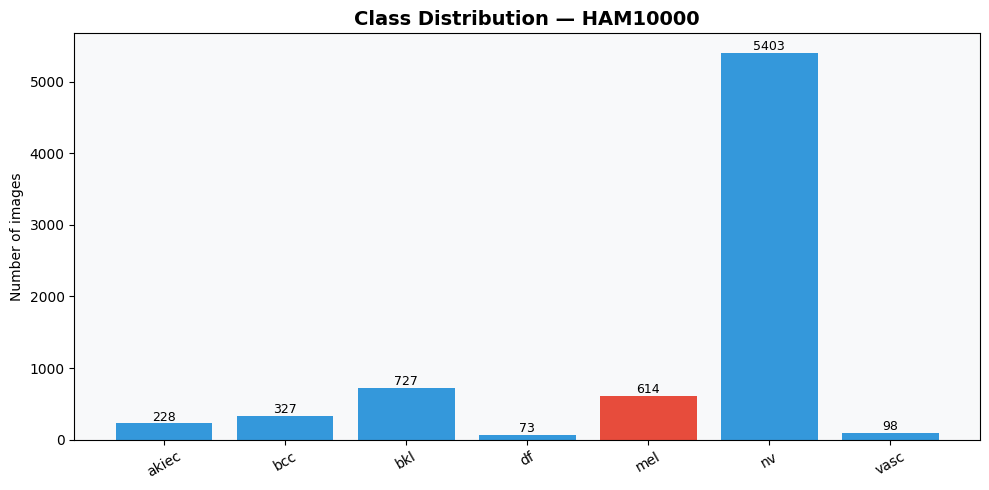

In [16]:
dist = df['dx'].value_counts().reindex(CLASS_NAMES, fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if c == 'mel' else '#3498db' for c in dist.index]
bars = ax.bar(dist.index, dist.values, color=colors)
ax.set_title('Class Distribution — HAM10000', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of images')
ax.tick_params(axis='x', rotation=30)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
            str(int(bar.get_height())), ha='center', fontsize=9)
ax.set_facecolor('#f8f9fa')
plt.tight_layout()
plt.show()

### 4.2 Sample Images per Class

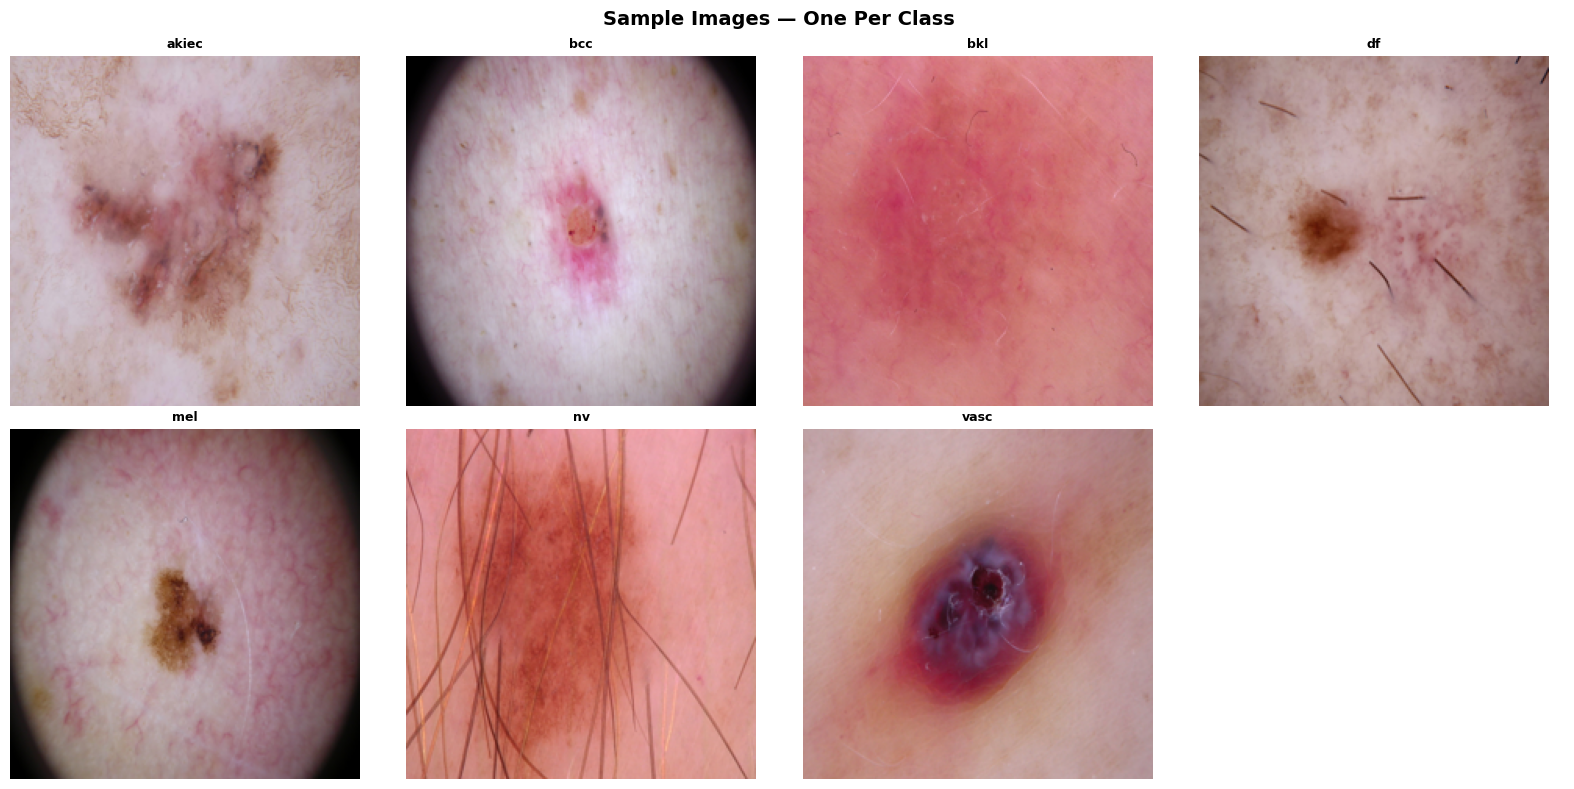

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, cls_name in enumerate(CLASS_NAMES):
    sample_path = df[df['dx'] == cls_name]['path'].sample(1, random_state=7).values[0]
    img = Image.open(sample_path).resize((224, 224))
    axes[i].imshow(img)
    axes[i].set_title(f'{cls_name}', fontsize=9, fontweight='bold')
    axes[i].axis('off')

axes[7].axis('off')   # hide extra subplot
fig.suptitle('Sample Images — One Per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.3 Age Distribution by Class

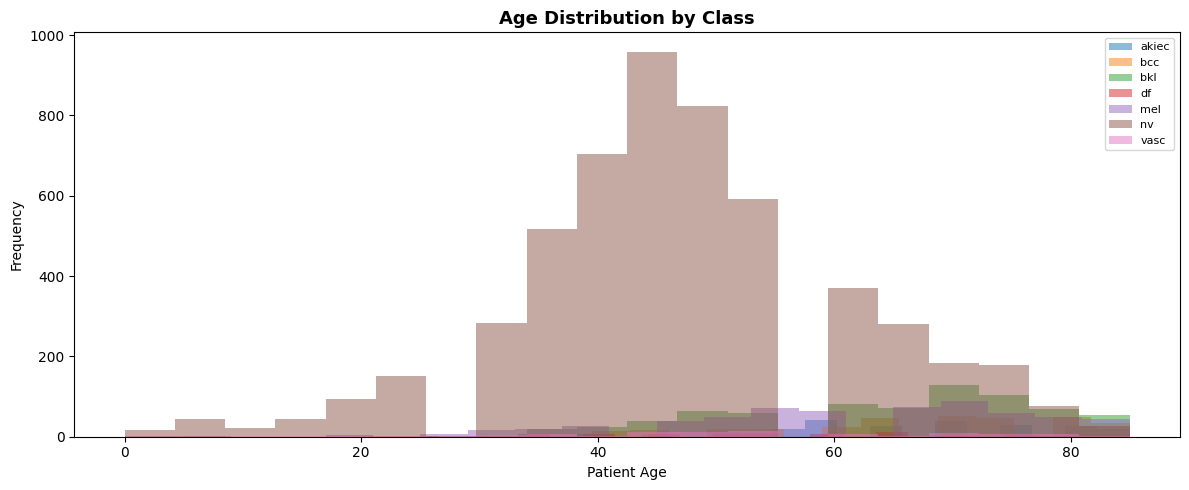

In [19]:
fig, ax = plt.subplots(figsize=(12, 5))
for cls_name in CLASS_NAMES:
    subset = df[df['dx'] == cls_name]['age'].dropna()
    ax.hist(subset, bins=20, alpha=0.5, label=cls_name)
ax.set_title('Age Distribution by Class', fontsize=13, fontweight='bold')
ax.set_xlabel('Patient Age')
ax.set_ylabel('Frequency')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 4.4 Sex Distribution per Class

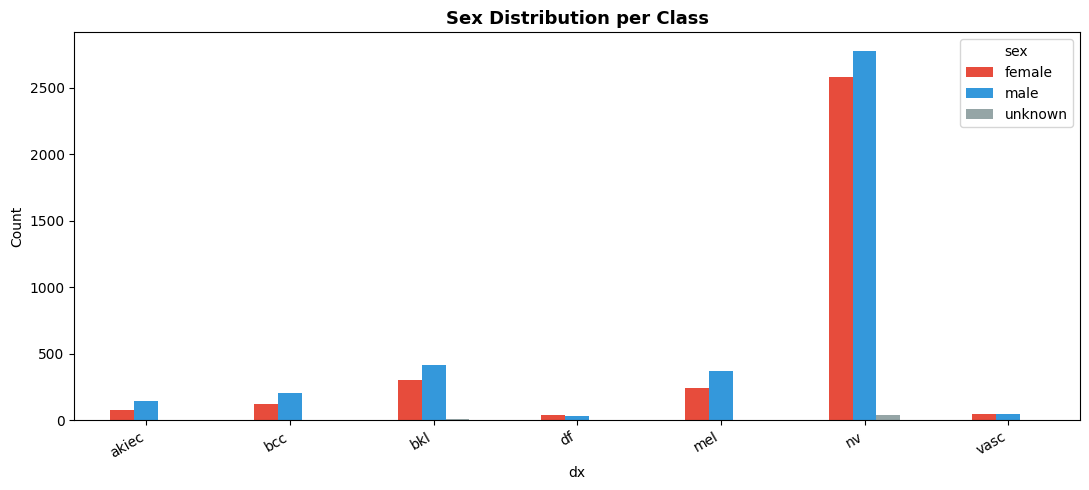

In [21]:
sex_pivot = df.groupby(['dx', 'sex']).size().unstack(fill_value=0)
sex_pivot.plot(kind='bar', figsize=(11, 5), color=['#e74c3c', '#3498db', '#95a5a6'])
plt.title('Sex Distribution per Class', fontsize=13, fontweight='bold')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### 4.5 Lesion Location by Class

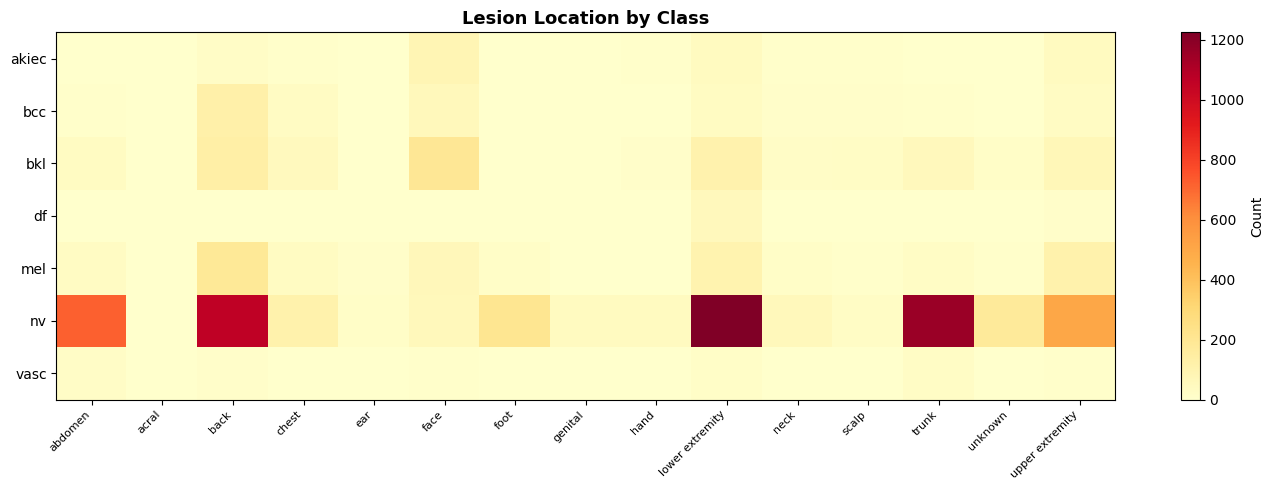

In [23]:
loc_counts = df.groupby(['dx', 'localization']).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(loc_counts.values, aspect='auto', cmap='YlOrRd')
ax.set_yticks(range(len(loc_counts.index)))
ax.set_yticklabels(loc_counts.index)
ax.set_xticks(range(len(loc_counts.columns)))
ax.set_xticklabels(loc_counts.columns, rotation=45, ha='right', fontsize=8)
plt.colorbar(im, ax=ax, label='Count')
ax.set_title('Lesion Location by Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.6 Diagnosis Confirmation Method

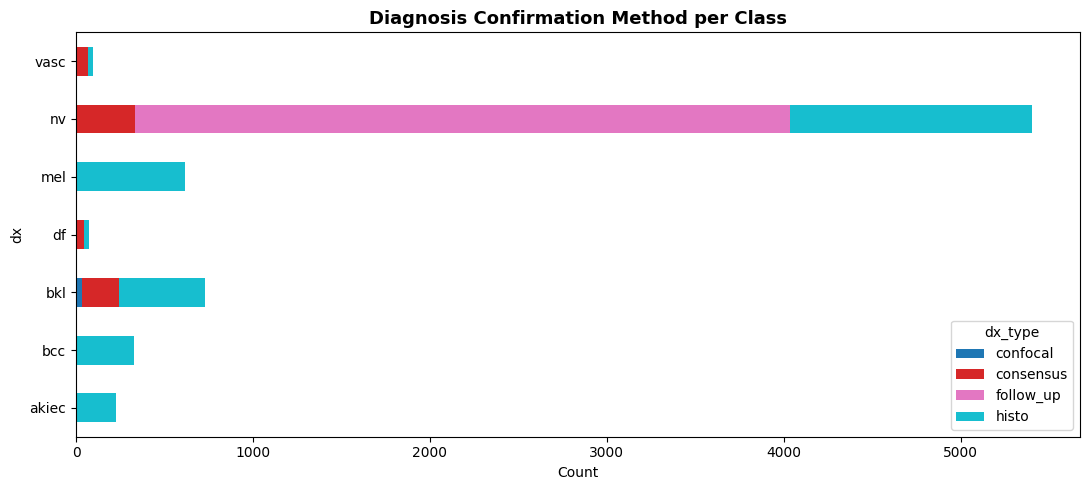

In [25]:
dx_type_counts = df.groupby(['dx', 'dx_type']).size().unstack(fill_value=0)
dx_type_counts.plot(kind='barh', stacked=True, figsize=(11, 5),
                     colormap='tab10')
plt.title('Diagnosis Confirmation Method per Class', fontsize=13, fontweight='bold')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

### 4.7 Melanoma vs Nevi — Most Confused Pair

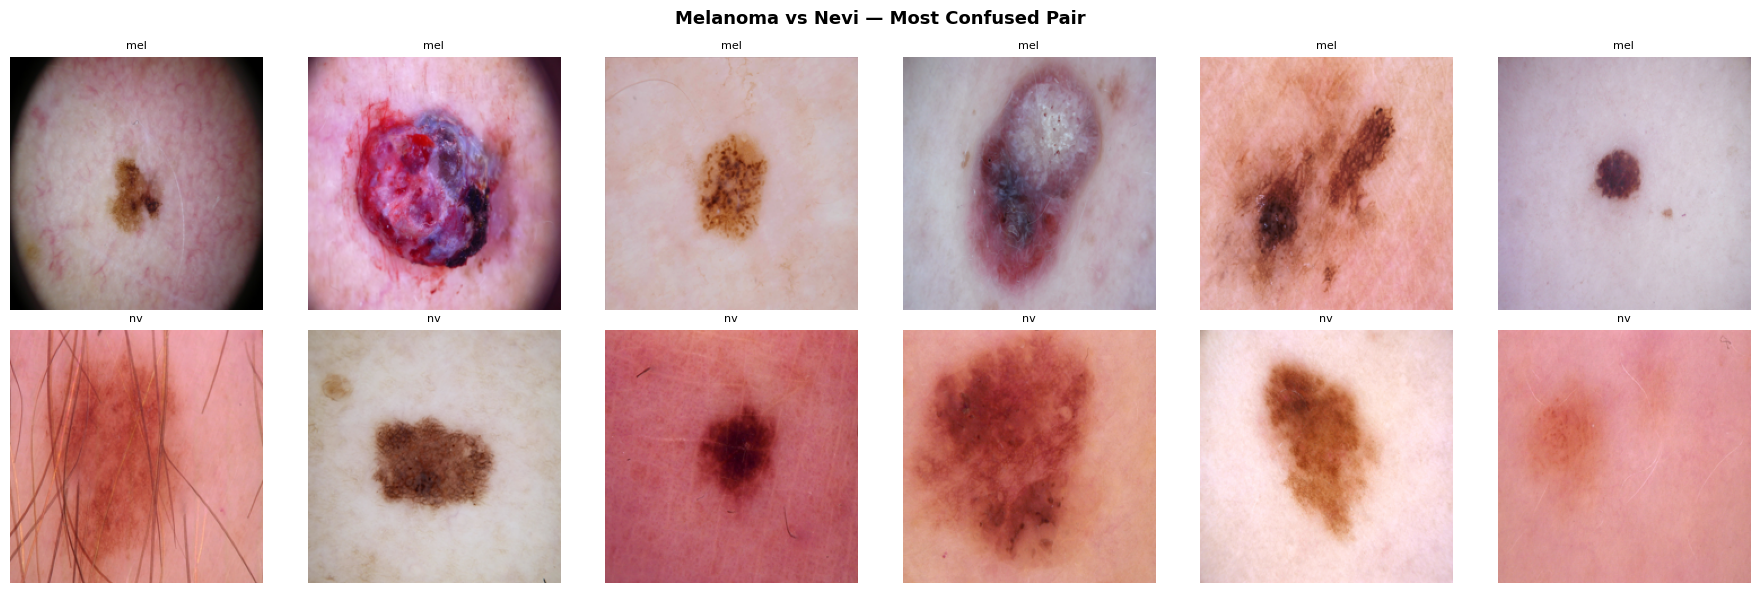

In [27]:
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for row, cls in enumerate(['mel', 'nv']):
    samples = df[df['dx'] == cls]['path'].sample(6, random_state=7).values
    for col, path in enumerate(samples):
        axes[row][col].imshow(Image.open(path).resize((224, 224)))
        axes[row][col].set_title(f'{cls}', fontsize=8)
        axes[row][col].axis('off')
axes[0][0].set_ylabel('Melanoma', fontsize=10, fontweight='bold', rotation=90, labelpad=5)
axes[1][0].set_ylabel('Nevi', fontsize=10, fontweight='bold', rotation=90, labelpad=5)
fig.suptitle('Melanoma vs Nevi — Most Confused Pair', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.8 Lesion Localization Overview

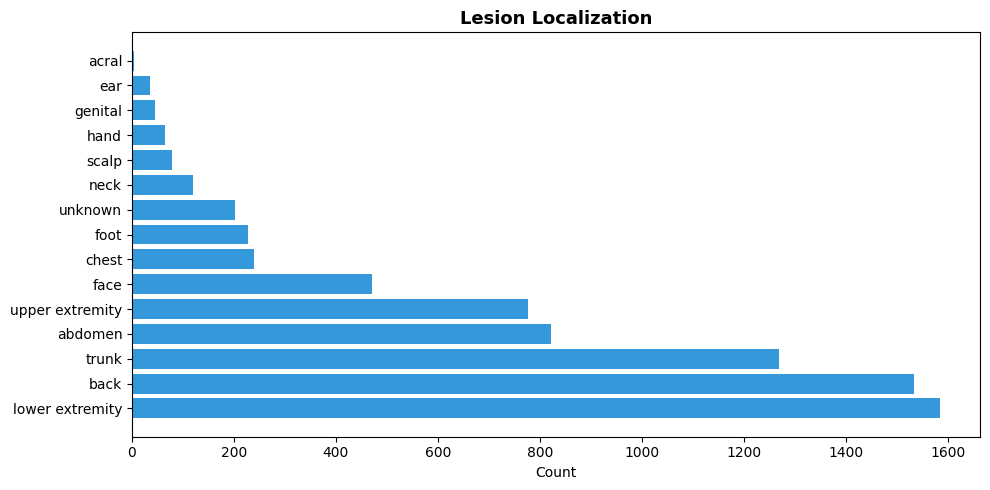

In [29]:
loc = df['localization'].value_counts()
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(loc.index, loc.values, color='#3498db')
ax.set_title('Lesion Localization', fontsize=13, fontweight='bold')
ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

## 5. Train / Validation / Test Split

In [30]:
train_df, tmp_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=SEED)
val_df,  test_df = train_test_split(tmp_df, test_size=0.5, stratify=tmp_df['label'], random_state=SEED)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)
print(f'Train {len(train_df)} | Val {len(val_df)} | Test {len(test_df)}')

Train 5976 | Val 747 | Test 747


## 6. Dataset, Transforms & Data Loaders

In [31]:
# HAM10000-specific stats
mean = [0.7630, 0.5456, 0.5700]
std  = [0.1409, 0.1526, 0.1695]

train_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE + 16, IMG_SIZE + 16)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),
])
eval_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

class SkinDataset(Dataset):
    def __init__(self, df, tfm):
        self.paths  = df['path'].tolist()
        self.labels = df['label'].tolist()
        self.tfm    = tfm
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        return self.tfm(Image.open(self.paths[i]).convert('RGB')), self.labels[i]

# WeightedRandomSampler — caps dominance of 'nv' class
counts    = np.bincount(train_df['label'].values, minlength=len(CLASS_NAMES)).astype(float)
# Soft weighting: sqrt dampens extreme ratios so val dist isn't totally alien
w_class   = 1.0 / np.sqrt(counts + 1)
w_sample  = w_class[train_df['label'].values]
sampler   = WeightedRandomSampler(w_sample, num_samples=len(w_sample), replacement=True)

train_ds = SkinDataset(train_df, train_tfm)
val_ds   = SkinDataset(val_df,   eval_tfm)
test_ds  = SkinDataset(test_df,  eval_tfm)

train_dl = DataLoader(train_ds, batch_size=BATCH, sampler=sampler, num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,   num_workers=2, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,   num_workers=2, pin_memory=True)

## 7. Model Architecture

In [32]:
# EfficientNetV2-S: better accuracy/speed tradeoff than DenseNet121
model = models.efficientnet_v2_s(weights='IMAGENET1K_V1')
in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features, len(CLASS_NAMES))
)
model = model.to(DEVICE)

# ── Loss: label-smoothed cross entropy with class weights ────────────────────
# Focal loss caused near-zero loss values with the imbalanced alpha — switching
# to weighted CE + label smoothing is more stable and easier to tune.
class_weights = torch.tensor(1.0 / np.sqrt(counts + 1), dtype=torch.float32)
class_weights = (class_weights / class_weights.sum() * len(CLASS_NAMES)).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

# Two-phase LR: lower LR for frozen backbone features, higher for head
head_params     = list(model.classifier.parameters())
backbone_params = [p for p in model.parameters() if not any(p is q for q in head_params)]

optimizer = torch.optim.AdamW([
    {'params': backbone_params, 'lr': LR * 0.1},
    {'params': head_params,     'lr': LR}
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=[LR * 0.1, LR],
    steps_per_epoch=len(train_dl), epochs=EPOCHS, pct_start=0.2
)

print(f'Params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Params: 20,186,455


## 8. Evaluation Helper

In [33]:
def evaluate(loader):
    """Returns loss, overall accuracy, and melanoma recall."""
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    mel_tp, mel_fn = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out  = model(imgs)
            loss = criterion(out, labels)
            preds = out.argmax(1)
            total_loss += loss.item() * len(imgs)
            correct    += (preds == labels).sum().item()
            n          += len(imgs)
            is_mel      = labels == MEL_IDX
            mel_tp     += (preds[is_mel] == MEL_IDX).sum().item()
            mel_fn     += (preds[is_mel] != MEL_IDX).sum().item()
    mel_recall = mel_tp / (mel_tp + mel_fn + 1e-9)
    return total_loss / n, correct / n, mel_recall

## 9. Training

### 9.1 Training Loop

In [34]:
best_mel_recall = 0.0
history = []

print(f'{"Ep":>4} | {"Tr Loss":>8} {"Tr Acc":>7} | {"Vl Loss":>8} {"Vl Acc":>7} | {"Mel Rec":>7}')
print('-' * 62)

for ep in range(1, EPOCHS + 1):
    # ── train
    model.train()
    tr_loss, tr_correct, tr_n = 0.0, 0, 0
    for imgs, labels in train_dl:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        tr_loss    += loss.item() * len(imgs)
        tr_correct += (out.argmax(1) == labels).sum().item()
        tr_n       += len(imgs)

    tr_loss /= tr_n
    tr_acc   = tr_correct / tr_n

    # ── validate
    vl_loss, vl_acc, mel_rec = evaluate(val_dl)
    history.append((tr_loss, tr_acc, vl_loss, vl_acc, mel_rec))

    tag = ''
    if mel_rec > best_mel_recall:
        best_mel_recall = mel_rec
        torch.save(model.state_dict(), SAVE_PATH)
        tag = '  ✓'

    print(f'{ep:>4} | {tr_loss:>8.4f} {tr_acc:>7.3f} | {vl_loss:>8.4f} {vl_acc:>7.3f} | {mel_rec:>7.3f}{tag}')

print(f'\nBest val melanoma recall: {best_mel_recall:.3f}')

  Ep |  Tr Loss  Tr Acc |  Vl Loss  Vl Acc | Mel Rec
--------------------------------------------------------------
   1 |   2.0644   0.230 |   2.2124   0.353 |   0.194  ✓
   2 |   1.9272   0.314 |   2.0537   0.387 |   0.306  ✓
   3 |   1.5403   0.512 |   1.7607   0.609 |   0.581  ✓
   4 |   1.2524   0.663 |   1.6069   0.722 |   0.613  ✓
   5 |   1.0986   0.733 |   1.5340   0.742 |   0.661  ✓
   6 |   1.0231   0.779 |   1.5294   0.774 |   0.565
   7 |   0.9505   0.806 |   1.5385   0.767 |   0.629
   8 |   0.8963   0.829 |   1.5134   0.790 |   0.484
   9 |   0.8754   0.850 |   1.5442   0.762 |   0.710  ✓
  10 |   0.8420   0.869 |   1.4840   0.817 |   0.694
  11 |   0.8344   0.877 |   1.4978   0.811 |   0.565
  12 |   0.8017   0.894 |   1.5110   0.815 |   0.629
  13 |   0.7916   0.900 |   1.4754   0.838 |   0.597
  14 |   0.7722   0.902 |   1.5075   0.819 |   0.677
  15 |   0.7642   0.914 |   1.5266   0.813 |   0.597
  16 |   0.7605   0.916 |   1.5156   0.813 |   0.613
  17 |   0.7507   

### 9.2 Best Epoch Summary

In [42]:
h = np.array(history)
best_ep = int(h[:, 4].argmax()) + 1
print(f"Best Epoch : {best_ep}/{EPOCHS}")
print(f"Train Loss : {h[best_ep-1, 0]:.4f}  |  Train Acc : {h[best_ep-1, 1]:.3f}")
print(f"Val Loss   : {h[best_ep-1, 2]:.4f}  |  Val Acc   : {h[best_ep-1, 3]:.3f}")
print(f"Mel Recall : {h[best_ep-1, 4]:.3f}")

Best Epoch : 9/25
Train Loss : 0.8754  |  Train Acc : 0.850
Val Loss   : 1.5442  |  Val Acc   : 0.762
Mel Recall : 0.710


### 9.3 Training Curves

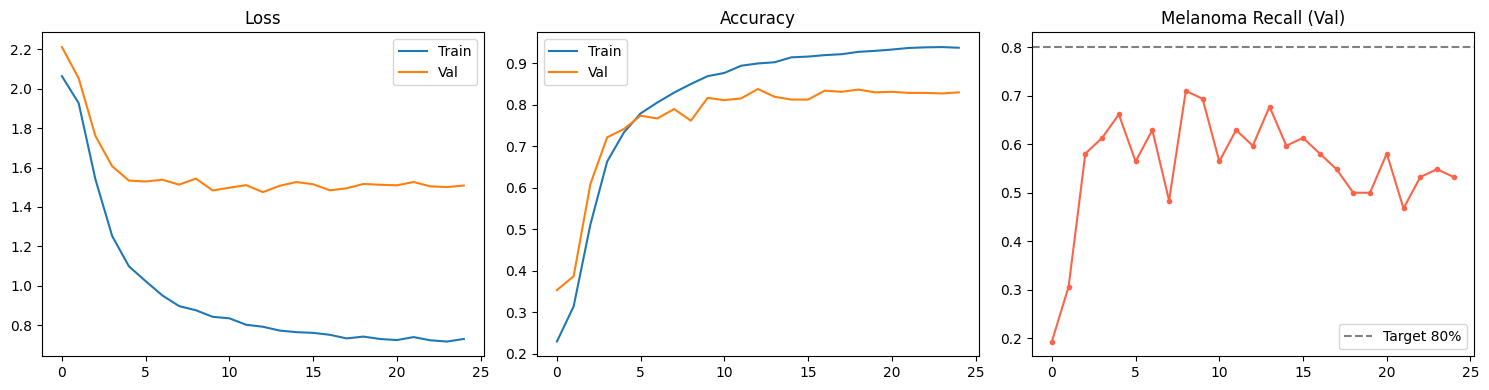

In [35]:
h = np.array(history)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(h[:,0], label='Train'); axes[0].plot(h[:,2], label='Val')
axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(h[:,1], label='Train'); axes[1].plot(h[:,3], label='Val')
axes[1].set_title('Accuracy'); axes[1].legend()
axes[2].plot(h[:,4], color='tomato', marker='o', markersize=3)
axes[2].axhline(0.80, linestyle='--', color='gray', label='Target 80%')
axes[2].set_title('Melanoma Recall (Val)'); axes[2].legend()
plt.tight_layout(); plt.show()

## 10. Evaluation

### 10.1 Test Set Evaluation with Threshold Tuning

In [36]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import torch.nn.functional as F

# Load the best checkpoint saved during training
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

# ── Step 1: Collect raw probabilities & ground truth ────────────────────────
all_probs, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_dl:
        probs = F.softmax(model(imgs.to(DEVICE)), dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.numpy())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)
mel_probs  = all_probs[:, MEL_IDX]
true_mel   = (all_labels == MEL_IDX)

# ── Step 2: Scan thresholds to find the lowest one that hits ≥80% recall ────
best_thresh = 0.5   # default argmax equivalent
best_recall = 0.0

print(f'{"Thresh":>7} | {"Mel Recall":>10} | {"Precision":>9} | {"F1":>6}')
print('-' * 42)

for t in np.arange(0.10, 0.55, 0.05):
    pred_mel = mel_probs >= t
    tp  = (pred_mel &  true_mel).sum()
    fn  = (~pred_mel &  true_mel).sum()
    fp  = (pred_mel & ~true_mel).sum()
    rec  = tp / (tp + fn + 1e-9)
    prec = tp / (tp + fp + 1e-9)
    f1   = 2 * rec * prec / (rec + prec + 1e-9)
    mark = ' ← target' if rec >= 0.80 else ''
    print(f'{t:>7.2f} | {rec:>10.3f} | {prec:>9.3f} | {f1:>6.3f}{mark}')
    # Track the best threshold that achieves the recall target
    if rec >= 0.80 and f1 > best_recall:
        best_recall = f1
        best_thresh = t

# ── Step 3: Re-predict using chosen threshold ────────────────────────────────
print(f'\nUsing melanoma threshold = {best_thresh:.2f}')

# Start from argmax predictions, then override mel based on threshold
all_preds = np.argmax(all_probs, axis=1)
mel_override = mel_probs >= best_thresh
all_preds[mel_override] = MEL_IDX

# ── Step 4: Final metrics ────────────────────────────────────────────────────
tp = ((all_preds == MEL_IDX) & true_mel).sum()
fn = ((all_preds != MEL_IDX) & true_mel).sum()
test_mel_recall = tp / (tp + fn + 1e-9)
test_acc = (all_preds == all_labels).sum() / len(all_labels)

print(f'\n{"─"*50}')
print(classification_report(all_labels, all_preds,
                             target_names=CLASS_NAMES, digits=3))
print(f'Overall accuracy  : {test_acc:.3f}')
print(f'Melanoma recall   : {test_mel_recall:.3f}  (target >0.80)')
print('✅ Target met!' if test_mel_recall >= 0.80
      else '⚠️  Still below target — try retraining tweaks.')

 Thresh | Mel Recall | Precision |     F1
------------------------------------------
   0.10 |      0.967 |     0.216 |  0.353 ← target
   0.15 |      0.951 |     0.250 |  0.396 ← target
   0.20 |      0.902 |     0.275 |  0.421 ← target
   0.25 |      0.869 |     0.283 |  0.427 ← target
   0.30 |      0.836 |     0.319 |  0.462 ← target
   0.35 |      0.770 |     0.320 |  0.452
   0.40 |      0.754 |     0.341 |  0.469
   0.45 |      0.721 |     0.373 |  0.492
   0.50 |      0.689 |     0.400 |  0.506

Using melanoma threshold = 0.30

──────────────────────────────────────────────────
              precision    recall  f1-score   support

       akiec      0.538     0.609     0.571        23
         bcc      0.628     0.818     0.711        33
         bkl      0.822     0.514     0.632        72
          df      0.462     0.750     0.571         8
         mel      0.317     0.836     0.459        61
          nv      0.969     0.802     0.877       540
        vasc      0.750     

### 10.2 Confusion Matrix

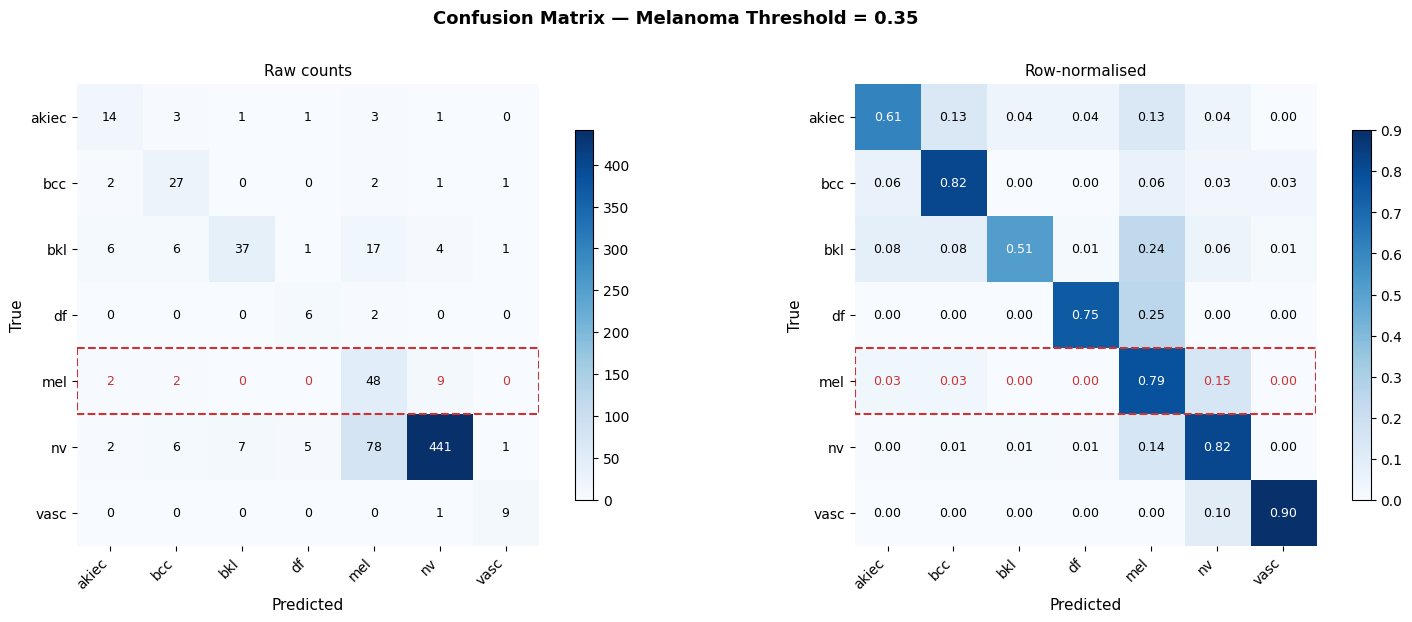


Melanoma at threshold 0.35:
  TP=48  FN=13  FP=102
  Recall    : 0.787
  Precision : 0.320
⚠️  Below 0.80


In [37]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

MEL_THRESHOLD = 0.35

# Apply threshold: override to melanoma where mel prob >= 0.35
all_preds_t35 = np.argmax(all_probs, axis=1)
all_preds_t35[mel_probs >= MEL_THRESHOLD] = MEL_IDX

# Build matrix
cm = confusion_matrix(all_labels, all_preds_t35)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Confusion Matrix — Melanoma Threshold = {MEL_THRESHOLD}',
             fontsize=13, fontweight='bold', y=1.02)

for ax, data, title, fmt in [
    (axes[0], cm,      'Raw counts',      'd'),
    (axes[1], cm_norm, 'Row-normalised', '.2f'),
]:
    im = ax.imshow(data, cmap='Blues', vmin=0)
    ax.set_xticks(range(len(CLASS_NAMES)))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=10)
    ax.set_yticks(range(len(CLASS_NAMES)))
    ax.set_yticklabels(CLASS_NAMES, fontsize=10)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('True', fontsize=11)
    ax.set_title(title, fontsize=11)
    threshold = data.max() * 0.5
    for i in range(len(CLASS_NAMES)):
        for j in range(len(CLASS_NAMES)):
            color = 'white' if data[i, j] > threshold else 'black'
            # Highlight the melanoma row in red if a miss
            if i == MEL_IDX and j != MEL_IDX:
                color = '#cc3333'
            ax.text(j, i, format(data[i, j], fmt),
                    ha='center', va='center', fontsize=9, color=color)
    plt.colorbar(im, ax=ax, shrink=0.8)

# Highlight melanoma row/col
for ax in axes:
    for spine in ax.spines.values(): spine.set_visible(False)
    ax.add_patch(plt.Rectangle(
        (-0.5, MEL_IDX - 0.5), len(CLASS_NAMES), 1,
        fill=False, edgecolor='#cc3333', lw=1.5, linestyle='--'
    ))

# Print melanoma-specific stats
mel_row = cm[MEL_IDX]
tp  = cm[MEL_IDX, MEL_IDX]
fn  = mel_row.sum() - tp
fp  = cm[:, MEL_IDX].sum() - tp
rec  = tp / (tp + fn + 1e-9)
prec = tp / (tp + fp + 1e-9)

plt.tight_layout()
plt.show()

print(f'\nMelanoma at threshold {MEL_THRESHOLD}:')
print(f'  TP={tp}  FN={fn}  FP={fp}')
print(f'  Recall    : {rec:.3f}')
print(f'  Precision : {prec:.3f}')
print('✅ Recall target met!' if rec >= 0.80 else '⚠️  Below 0.80')

### 10.3 Melanoma Threshold Tuning (Fine-Grained Scan)

In [38]:
all_probs, all_labels2 = [], []
model.eval()
with torch.no_grad():
    for imgs, labels in test_dl:
        probs = F.softmax(model(imgs.to(DEVICE)), dim=1).cpu()
        all_probs.extend(probs.numpy())
        all_labels2.extend(labels.numpy())

all_probs   = np.array(all_probs)
all_labels2 = np.array(all_labels2)
mel_probs   = all_probs[:, MEL_IDX]
true_mel    = (all_labels2 == MEL_IDX)

print(f'{"Thresh":>7} | {"Mel Recall":>10} | {"Precision":>9} | {"F1":>6}')
print('-' * 42)
for t in np.arange(0.15, 0.35, 0.05):
    pred_mel = mel_probs >= t
    tp = (pred_mel & true_mel).sum()
    fn = (~pred_mel & true_mel).sum()
    fp = (pred_mel & ~true_mel).sum()
    rec  = tp / (tp + fn + 1e-9)
    prec = tp / (tp + fp + 1e-9)
    f1   = 2 * rec * prec / (rec + prec + 1e-9)
    mark = ' ← ✓' if rec >= 0.80 else ''
    print(f'{t:>7.2f} | {rec:>10.3f} | {prec:>9.3f} | {f1:>6.3f}{mark}')

 Thresh | Mel Recall | Precision |     F1
------------------------------------------
   0.15 |      0.951 |     0.250 |  0.396 ← ✓
   0.20 |      0.902 |     0.275 |  0.421 ← ✓
   0.25 |      0.869 |     0.283 |  0.427 ← ✓
   0.30 |      0.836 |     0.319 |  0.462 ← ✓


### 10.4 ROC Curves — One vs Rest

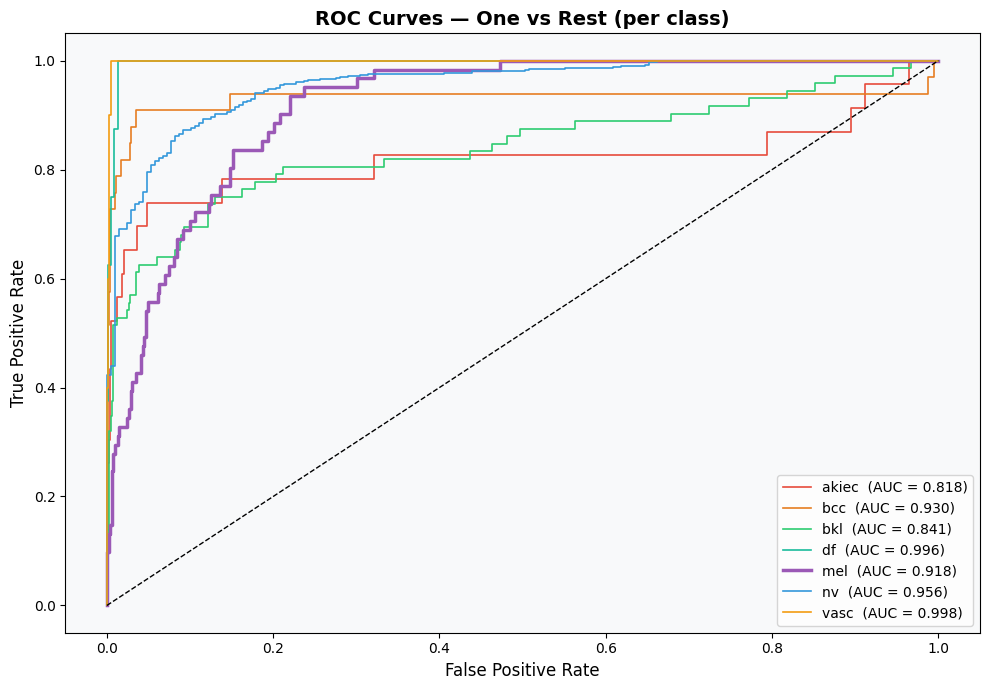

In [43]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_bin = label_binarize(all_labels, classes=list(range(len(CLASS_NAMES))))

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c', '#e67e22', '#2ecc71', '#1abc9c', '#9b59b6', '#3498db', '#f39c12']

for i, (cls, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    lw = 2.5 if cls == 'mel' else 1.2
    ax.plot(fpr, tpr, color=color, lw=lw, label=f"{cls}  (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — One vs Rest (per class)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_facecolor('#f8f9fa')
plt.tight_layout()
plt.show()

### 10.5 Misclassified Samples

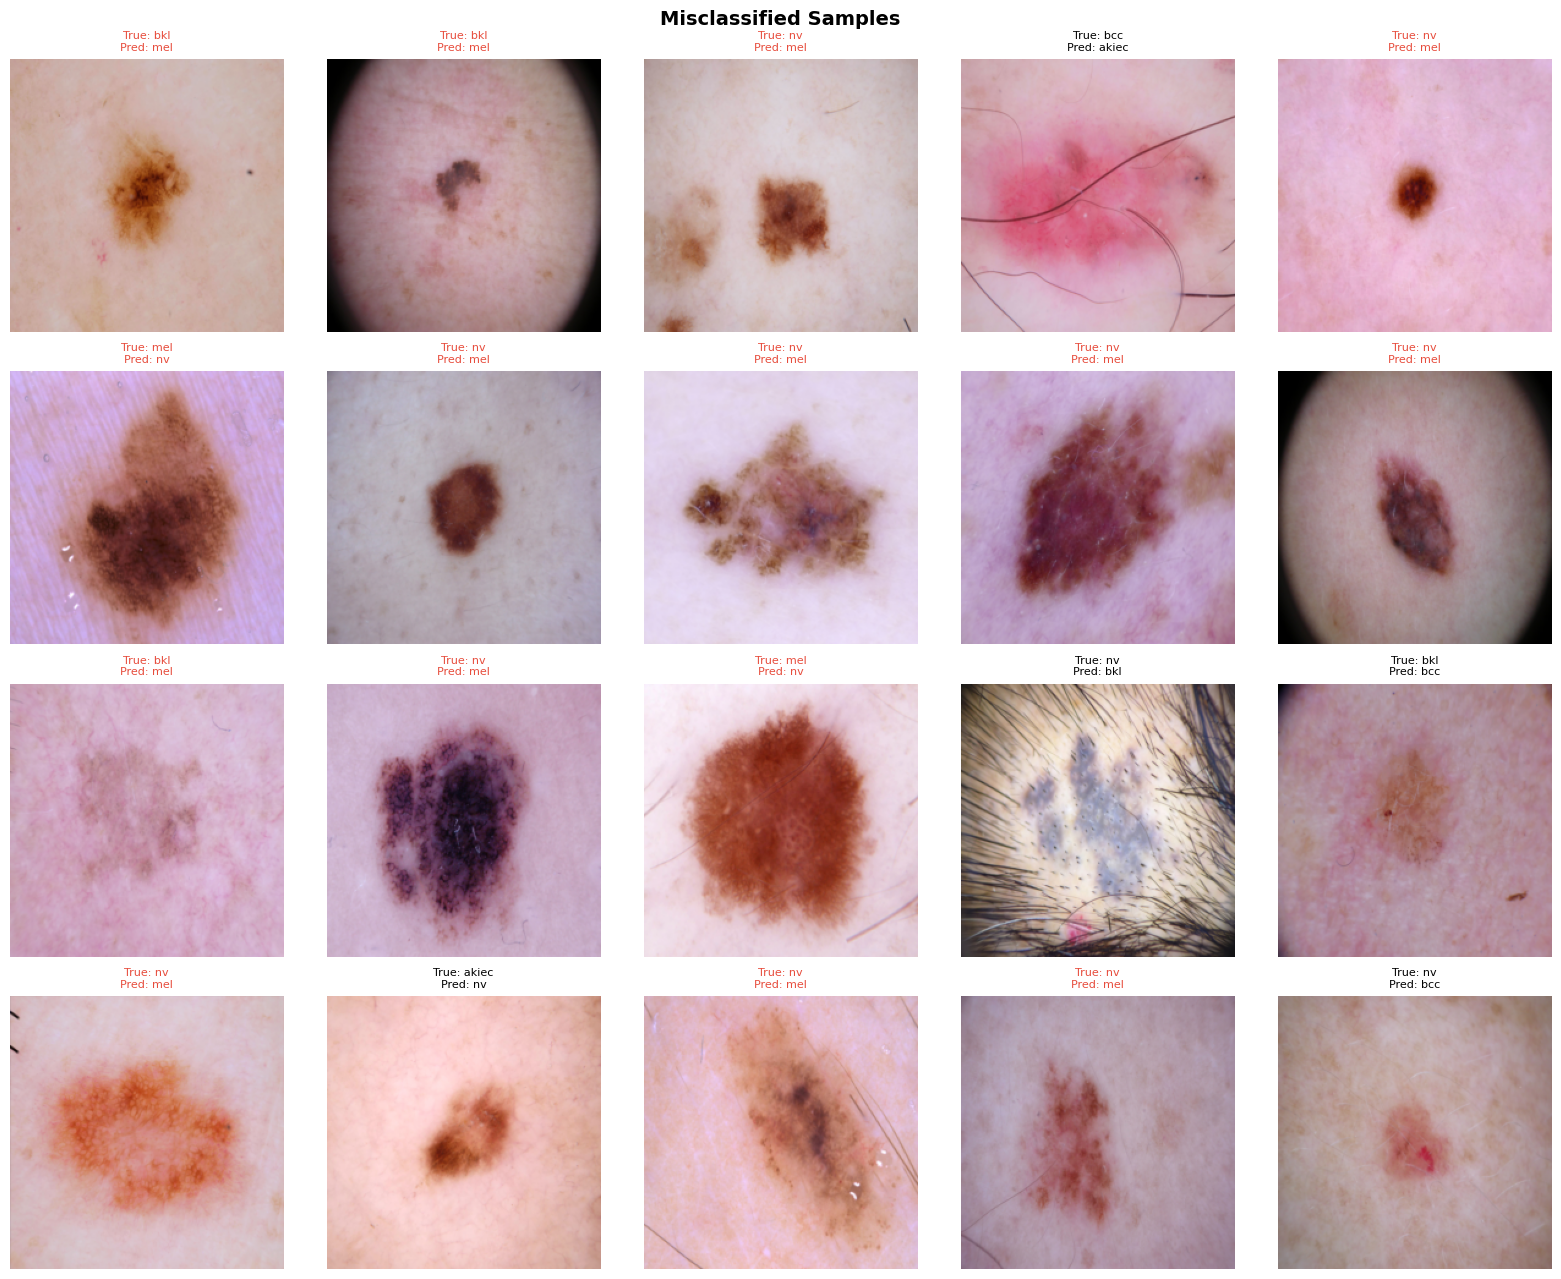

In [44]:
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

wrong_imgs, wrong_true, wrong_pred = [], [], []

with torch.no_grad():
    for imgs, labels in test_dl:
        probs = F.softmax(model(imgs.to(DEVICE)), dim=1).cpu().numpy()
        mel_p = probs[:, MEL_IDX]
        preds = np.argmax(probs, axis=1)
        preds[mel_p >= MEL_THRESHOLD] = MEL_IDX
        mask = preds != labels.numpy()
        for idx in np.where(mask)[0]:
            if len(wrong_imgs) >= 20:
                break
            wrong_imgs.append(imgs[idx])
            wrong_true.append(labels[idx].item())
            wrong_pred.append(preds[idx])
        if len(wrong_imgs) >= 20:
            break

mean_t = torch.tensor(mean).view(3, 1, 1)
std_t  = torch.tensor(std).view(3, 1, 1)

fig, axes = plt.subplots(4, 5, figsize=(16, 13))
fig.suptitle('Misclassified Samples', fontsize=14, fontweight='bold')

for ax, img_t, true_l, pred_l in zip(axes.flat, wrong_imgs, wrong_true, wrong_pred):
    img = (img_t * std_t + mean_t).clamp(0, 1).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(f"True: {CLASS_NAMES[true_l]}\nPred: {CLASS_NAMES[pred_l]}",
                 fontsize=8,
                 color='#e74c3c' if true_l == MEL_IDX or pred_l == MEL_IDX else 'black')
    ax.axis('off')

for ax in axes.flat[len(wrong_imgs):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## 11. Save & Export

### 11.1 Mount Google Drive

In [39]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 11.2 Download Model Checkpoint

In [40]:
# ── Cell 14: Download Model ───────────────────────────────────────────────────
from google.colab import files
files.download(SAVE_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>